# Smart Default

В этом проекте я анализирую данные 30 000 клиентов кредитных карт и проверяю, какие признаки связаны с дефолтом в следующем месяце. Данные подготовлены в PostgreSQL во view `public.credit_features`, дальнейший анализ выполнен в Python.

`default_next_month = 1` означает дефолт, `0` — отсутствие дефолта. Здесь проверяются связи между признаками, а не причинность.

## Загрузка данных

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine

Загружаю переменные подключения из `.env`, чтобы не хранить логин и пароль в ноутбуке.

In [2]:
current_path = Path.cwd()
possible_paths = [current_path / ".env", current_path.parent / ".env"]
env_path = next((path for path in possible_paths if path.exists()), None)

assert env_path is not None, "Файл .env не найден"
load_dotenv(env_path, override=True)

required_variables = [
    "DB_HOST",
    "DB_PORT",
    "DB_NAME",
    "DB_USER",
    "DB_PASSWORD",
]
missing_variables = [
    variable for variable in required_variables if not os.getenv(variable)
]

assert not missing_variables, f"Не заполнены переменные: {missing_variables}"
print("Переменные окружения загружены.")

Переменные окружения загружены.


Подключаюсь к PostgreSQL и проверяю, что view `credit_features` доступно.

In [3]:
database_url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(database_url)

with engine.connect() as connection:
    connection_info = pd.read_sql(
        "SELECT current_database() AS database_name, "
        "current_schema() AS schema_name",
        connection,
    )
    feature_view = pd.read_sql(
        "SELECT table_schema, table_name "
        "FROM information_schema.views "
        "WHERE table_schema = 'public' "
        "AND table_name = 'credit_features'",
        connection,
    )

display(connection_info)
display(feature_view)

,database_name,schema_name
0,credit_risk_db,public


,table_schema,table_name
0,public,credit_features


Загружаю итоговую витрину. Одна строка соответствует одному клиенту.

In [4]:
query = "SELECT * FROM public.credit_features"

with engine.connect() as connection:
    df = pd.read_sql(query, connection)

print(f"Размер данных: {df.shape[0]:,} строк × {df.shape[1]} столбцов")

Размер данных: 30,000 строк × 35 столбцов


In [5]:
df.head()

,id,limit_bal,age,age_group,sex_name,education_name,marriage_name,pay_0,pay_2,pay_3,...,max_delay_status,delay_group,delayed_months_count,avg_bill_amt,avg_payment_amt,current_utilization_pct,avg_utilization_pct,bill_change_amt,payment_to_bill_pct,default_next_month
0,1,20000.0,24,under_30,female,university,married,2,2,-1,...,2,delay_2_months,2,1284.00,114.83,19.57,6.42,3913.0,8.94,1
1,2,120000.0,26,under_30,female,university,single,-1,2,0,...,2,delay_2_months,2,2846.17,833.33,2.24,2.37,-579.0,29.28,1
2,3,90000.0,34,30_39,female,university,single,0,0,0,...,0,no_delay,0,16942.17,1836.33,32.49,18.82,13690.0,10.84,0
3,4,50000.0,37,30_39,female,university,married,0,0,0,...,0,no_delay,0,38555.67,1398.00,93.98,77.11,17443.0,3.63,0
4,5,50000.0,57,50_59,male,university,married,-1,0,-1,...,0,no_delay,0,18223.17,9841.50,17.23,36.45,-10514.0,54.01,0


## Проверка качества данных

Сначала проверяю размер таблицы, уникальность id и дубликаты.

In [6]:
data_quality_summary = pd.Series(
    {
        "rows_count": len(df),
        "columns_count": df.shape[1],
        "unique_ids": df["id"].nunique(),
        "duplicated_ids": df["id"].duplicated().sum(),
    },
    name="value",
).to_frame()

data_quality_summary

,value
rows_count,30000
columns_count,35
unique_ids,30000
duplicated_ids,0


Проверяю пропуски и их долю.

In [7]:
missing_count = df.isna().sum()
missing_summary = pd.DataFrame(
    {
        "missing_count": missing_count[missing_count > 0],
        "missing_pct": (
            missing_count[missing_count > 0] / len(df) * 100
        ).round(2),
    }
).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_pct
payment_to_bill_pct,1071,3.57


Пропуски есть только в `payment_to_bill_pct`. Проверяю, связаны ли они с нулевым или отрицательным средним счётом.

In [8]:
bill_quality_summary = pd.Series(
    {
        "avg_bill_equal_zero": (df["avg_bill_amt"] == 0).sum(),
        "avg_bill_below_zero": (df["avg_bill_amt"] < 0).sum(),
        "avg_bill_non_positive": (df["avg_bill_amt"] <= 0).sum(),
    },
    name="clients_count",
).to_frame()

bill_quality_summary

,clients_count
avg_bill_equal_zero,870
avg_bill_below_zero,201
avg_bill_non_positive,1071


Количество неположительных средних счетов совпало с количеством пропусков. Эти строки не удаляю, потому что пропуски объяснимы способом расчёта признака.

Проверяю типы данных.

In [9]:
schema_summary = df.dtypes.astype(str).rename("dtype").to_frame()
schema_summary

,dtype
id,int64
limit_bal,float64
age,int64
age_group,str
sex_name,str
education_name,str
marriage_name,str
pay_0,int64
pay_2,int64
pay_3,int64


Типы соответствуют смыслу столбцов: категории хранятся как строки, финансовые показатели — как числа, id и статусы — как целые числа.

## Баланс дефолта

In [10]:
target_summary = (
    df["default_next_month"]
      .value_counts()
      .sort_index()
      .rename_axis("default_flag")
      .reset_index(name="clients_count")
)

target_summary["segment"] = target_summary["default_flag"].map(
    {0: "Без дефолта", 1: "Дефолт"}
)
target_summary["clients_share_pct"] = (
    target_summary["clients_count"] / len(df) * 100
).round(2)

target_summary[["default_flag", "segment", "clients_count", "clients_share_pct"]]

,default_flag,segment,clients_count,clients_share_pct
0,0,Без дефолта,23364,77.88
1,1,Дефолт,6636,22.12


Дефолт есть у **6 636 клиентов (22,12%)**, без дефолта — **23 364 клиента (77,88%)**. Основной класс заметно больше, поэтому дальше сравниваю именно доли внутри групп, а не только количество дефолтов.

## Описательная статистика

In [11]:
key_numeric_columns = [
    "age",
    "limit_bal",
    "avg_bill_amt",
    "avg_payment_amt",
    "current_utilization_pct",
    "avg_utilization_pct",
    "bill_change_amt",
    "payment_to_bill_pct",
    "max_delay_status",
    "delayed_months_count",
    "default_next_month",
]

numeric_summary = df[key_numeric_columns].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,30000.0,35.485500,9.217904,21.00,28.00,34.000,41.000,79.00
limit_bal,30000.0,167484.322667,129747.661567,10000.00,50000.00,140000.000,240000.000,1000000.00
avg_bill_amt,30000.0,44951.945459,63232.769857,-56043.17,4778.00,21044.830,57103.045,877313.83
avg_payment_amt,30000.0,5220.788208,10017.192505,0.00,1112.50,2393.500,5558.415,627344.33
current_utilization_pct,30000.0,42.370785,41.145088,-61.99,2.20,31.385,82.965,645.53
avg_utilization_pct,30000.0,37.294069,35.183635,-25.16,2.99,28.470,68.790,536.43
bill_change_amt,30000.0,12361.570400,43919.589474,-428791.00,-2961.50,923.500,19797.000,708323.00
payment_to_bill_pct,28929.0,48.478479,560.197013,0.00,4.25,9.370,62.140,79700.00
max_delay_status,30000.0,0.438733,1.345154,-2.00,0.00,0.000,2.000,8.00
delayed_months_count,30000.0,0.834200,1.554303,0.00,0.00,0.000,1.000,6.00


В данных есть отрицательные счета и отрицательная утилизация, а максимальная утилизация превышает 100%. Автоматически их не удаляю: это могут быть переплаты, возвраты, превышение лимита или особенности расчёта.

## Использование кредитного лимита

Проверяю гипотезу: чем большую часть лимита использует клиент, тем выше доля дефолтов. Беру среднюю утилизацию `avg_utilization_pct`.

In [12]:
df["utilization_group"] = pd.cut(
    df["avg_utilization_pct"],
    bins=[-np.inf, 0, 30, 50, 80, 100, np.inf],
    labels=[
        "0% и меньше",
        "0–30%",
        "30–50%",
        "50–80%",
        "80–100%",
        "Больше 100%",
    ],
)

utilization_stats = (
    df.groupby("utilization_group", observed=True)
      .agg(
          clients_count=("id", "count"),
          defaults_count=("default_next_month", "sum"),
          default_rate=("default_next_month", "mean"),
      )
)
utilization_stats["default_rate_pct"] = (
    utilization_stats["default_rate"] * 100
).round(2)

utilization_stats

,clients_count,defaults_count,default_rate,default_rate_pct
utilization_group,,,,
0% и меньше,1076,369,0.342937,34.29
0–30%,14195,2362,0.166397,16.64
30–50%,3675,759,0.206531,20.65
50–80%,5993,1529,0.255131,25.51
80–100%,4427,1401,0.316467,31.65
Больше 100%,634,216,0.340694,34.07


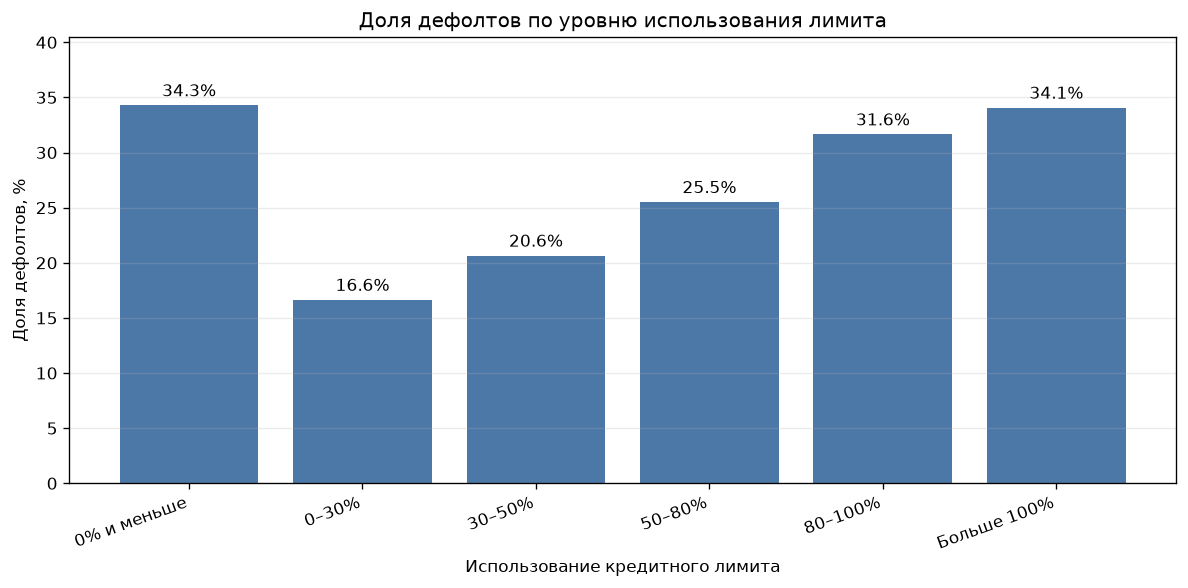

In [13]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

bars = ax.bar(
    utilization_stats.index.astype(str),
    utilization_stats["default_rate_pct"],
    color="#4C78A8",
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in utilization_stats["default_rate_pct"]],
    padding=3,
)
ax.set(
    title="Доля дефолтов по уровню использования лимита",
    xlabel="Использование кредитного лимита",
    ylabel="Доля дефолтов, %",
)
ax.set_ylim(0, utilization_stats["default_rate_pct"].max() * 1.18)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Среди клиентов с положительной утилизацией доля дефолтов растёт с **16,64%** при использовании до 30% лимита до **34,07%** при использовании более 100%. Связь получилась последовательной.

Группа «0% и меньше» выбивается: доля дефолтов в ней **34,29%**. Эту группу нужно рассматривать отдельно, потому что в неё могут попадать переплаты, возвраты и нулевые счета.

## Максимальная длительность просрочки

Проверяю гипотезу: чем серьёзнее просрочка, тем выше доля дефолтов.

In [14]:
delay_order = [
    "no_delay",
    "delay_1_month",
    "delay_2_months",
    "delay_3_plus",
]

delay_stats = (
    df.groupby("delay_group")
      .agg(
          clients_count=("id", "count"),
          defaults_count=("default_next_month", "sum"),
          default_rate=("default_next_month", "mean"),
      )
      .reindex(delay_order)
)
delay_stats["default_rate_pct"] = (
    delay_stats["default_rate"] * 100
).round(2)

delay_stats

,clients_count,defaults_count,default_rate,default_rate_pct
delay_group,,,,
no_delay,19931,2334,0.117104,11.71
delay_1_month,1689,422,0.249852,24.99
delay_2_months,7187,3130,0.435509,43.55
delay_3_plus,1193,750,0.628667,62.87


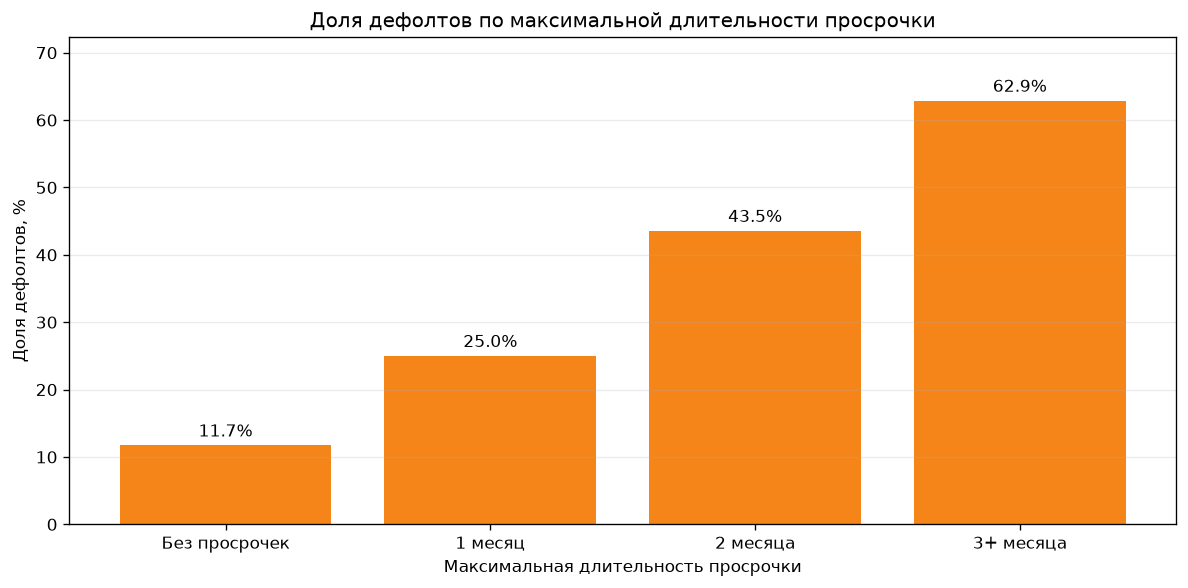

In [15]:
delay_axis_labels = ["Без просрочек", "1 месяц", "2 месяца", "3+ месяца"]

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
bars = ax.bar(
    delay_axis_labels,
    delay_stats["default_rate_pct"],
    color="#F58518",
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in delay_stats["default_rate_pct"]],
    padding=3,
)
ax.set(
    title="Доля дефолтов по максимальной длительности просрочки",
    xlabel="Максимальная длительность просрочки",
    ylabel="Доля дефолтов, %",
)
ax.set_ylim(0, delay_stats["default_rate_pct"].max() * 1.15)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Доля дефолтов растёт с **11,71%** у клиентов без просрочек до **62,87%** у клиентов с просрочкой три месяца и больше. Разница составляет **51,16 процентного пункта**, или примерно **5,37 раза**. Это один из самых сильных результатов анализа.

## Возраст

Сравниваю долю дефолтов по возрастным группам.

In [16]:
age_order = ["under_30", "30_39", "40_49", "50_59", "60_plus"]

age_stats = (
    df.groupby("age_group")
      .agg(
          clients_count=("id", "count"),
          defaults_count=("default_next_month", "sum"),
          default_rate=("default_next_month", "mean"),
      )
      .reindex(age_order)
)
age_stats["default_rate_pct"] = (
    age_stats["default_rate"] * 100
).round(2)

age_stats

,clients_count,defaults_count,default_rate,default_rate_pct
age_group,,,,
under_30,9618,2197,0.228426,22.84
30_39,11238,2276,0.202527,20.25
40_49,6464,1485,0.229734,22.97
50_59,2341,582,0.248612,24.86
60_plus,339,96,0.283186,28.32


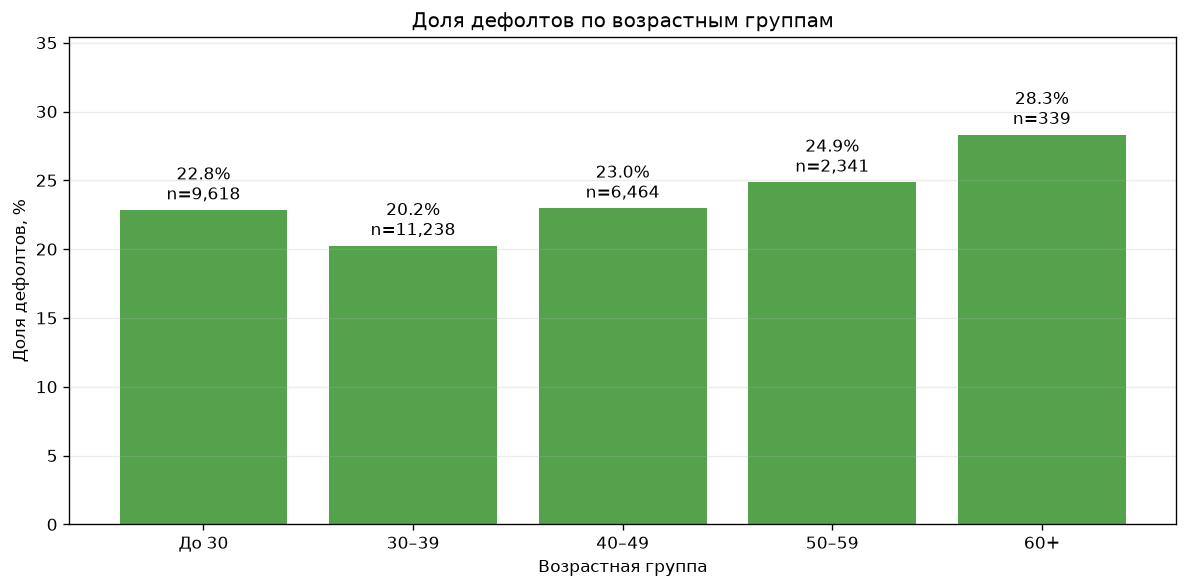

In [17]:
age_axis_labels = ["До 30", "30–39", "40–49", "50–59", "60+"]

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
bars = ax.bar(
    age_axis_labels,
    age_stats["default_rate_pct"],
    color="#54A24B",
)
age_labels = [
    f"{rate:.1f}%\nn={count:,}"
    for rate, count in zip(
        age_stats["default_rate_pct"],
        age_stats["clients_count"],
    )
]
ax.bar_label(bars, labels=age_labels, padding=3)
ax.set(
    title="Доля дефолтов по возрастным группам",
    xlabel="Возрастная группа",
    ylabel="Доля дефолтов, %",
)
ax.set_ylim(0, age_stats["default_rate_pct"].max() * 1.25)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Минимальная доля дефолтов у клиентов 30–39 лет — **20,25%**, максимальная в группе 60+ — **28,32%**. Строгого роста по всему возрастному диапазону нет. В группе 60+ только 339 клиентов, поэтому этот результат нужно трактовать осторожно. Возраст оказался заметно слабее просрочек.

## Частота просрочек

Проверяю, как количество месяцев с просрочкой связано с дефолтом.

In [18]:
delay_frequency_stats = (
    df.groupby("delayed_months_count")
      .agg(
          clients_count=("id", "count"),
          defaults_count=("default_next_month", "sum"),
          default_rate=("default_next_month", "mean"),
      )
      .sort_index()
)
delay_frequency_stats["default_rate_pct"] = (
    delay_frequency_stats["default_rate"] * 100
).round(2)

delay_frequency_stats

,clients_count,defaults_count,default_rate,default_rate_pct
delayed_months_count,,,,
0,19931,2334,0.117104,11.71
1,4426,1320,0.298238,29.82
2,1899,736,0.387572,38.76
3,1154,587,0.508666,50.87
4,951,545,0.573081,57.31
5,298,171,0.573826,57.38
6,1341,943,0.703207,70.32


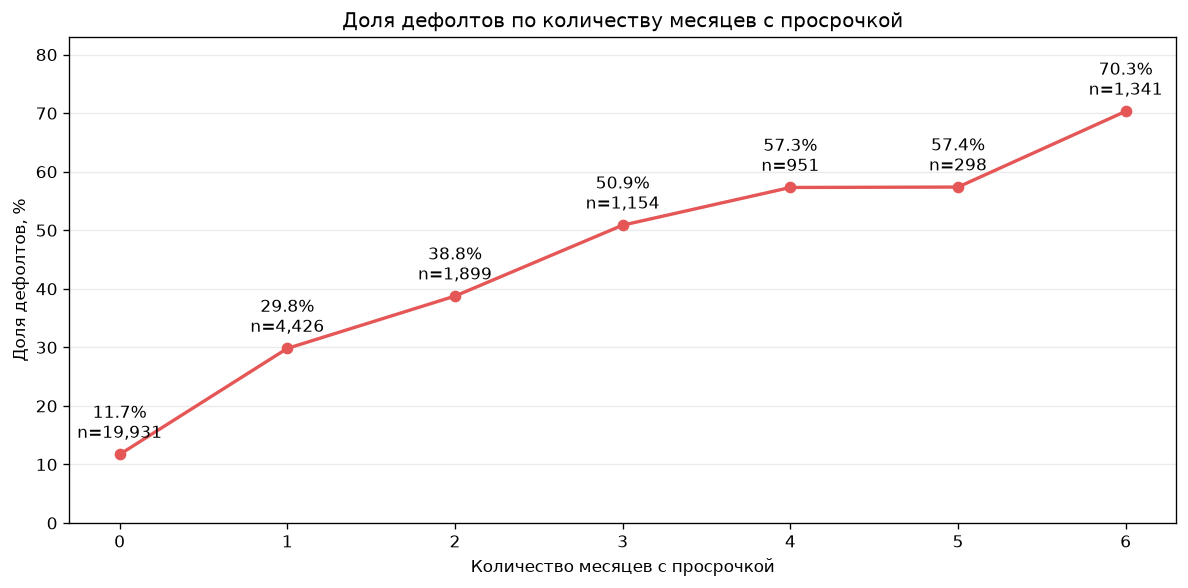

In [19]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

ax.plot(
    delay_frequency_stats.index,
    delay_frequency_stats["default_rate_pct"],
    color="#E45756",
    marker="o",
    linewidth=2,
)
for months, row in delay_frequency_stats.iterrows():
    ax.annotate(
        f'{row["default_rate_pct"]:.1f}%\nn={int(row["clients_count"]):,}',
        (months, row["default_rate_pct"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
    )

ax.set(
    title="Доля дефолтов по количеству месяцев с просрочкой",
    xlabel="Количество месяцев с просрочкой",
    ylabel="Доля дефолтов, %",
)
ax.set_xticks(delay_frequency_stats.index)
ax.set_ylim(0, delay_frequency_stats["default_rate_pct"].max() * 1.18)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Доля дефолтов растёт с **11,71%** без просрочек до **70,32%** при просрочках во всех шести месяцах. Уже при одной просрочке показатель повышается до **29,82%**, а при трёх месяцах превышает половину клиентов — **50,87%**.

## Изменение задолженности

Сравниваю клиентов, у которых задолженность уменьшилась, не изменилась или увеличилась. `bill_change_amt` рассчитан как разница между последним и шестым счётом.

In [20]:
decreased = (df['bill_change_amt'] < 0).sum()
unchanged = (df['bill_change_amt'] == 0).sum()
increased = (df['bill_change_amt'] > 0).sum()

print(decreased, unchanged, increased)

11402 1822 16776


In [21]:
conditions = [
    df['bill_change_amt'] < 0,
    df['bill_change_amt'] == 0,
    df['bill_change_amt'] > 0
]

choices = [
    "decreased",
    "unchanged",
    "increased"
]

df["debt_trend"] = np.select(
    conditions,
    choices,
    default="unknown"
)

In [22]:
df["debt_trend"].value_counts(dropna= False)

debt_trend
increased    16776
decreased    11402
unchanged     1822
Name: count, dtype: int64

In [23]:
debt_trend_stats = df.groupby("debt_trend").agg(
    clients_count = ("id", "count"),
    defaults_count=("default_next_month", "sum"),
    default_rate=("default_next_month", "mean")
)
debt_trend_stats["default_rate_pct"] = (debt_trend_stats["default_rate"] * 100).round(2)
debt_trend_stats

,clients_count,defaults_count,default_rate,default_rate_pct
debt_trend,,,,
decreased,11402,2948,0.258551,25.86
increased,16776,3087,0.184013,18.40
unchanged,1822,601,0.329857,32.99


In [24]:
change = ["decreased", "unchanged", "increased"]
debt_trend_stats = debt_trend_stats.reindex(change)
debt_trend_stats

,clients_count,defaults_count,default_rate,default_rate_pct
debt_trend,,,,
decreased,11402,2948,0.258551,25.86
unchanged,1822,601,0.329857,32.99
increased,16776,3087,0.184013,18.40


Результат оказался неожиданным: у клиентов с увеличившейся задолженностью доля дефолтов ниже, чем в остальных группах. Поэтому отдельно проверяю группу `unchanged`.

In [25]:
both_zero_mask = (
    (df["bill_amt1"] == 0)
    & (df["bill_amt6"] == 0)
    & (df["debt_trend"] == "unchanged")
)

same_nonzero_mask = (
    (df["bill_amt1"] != 0)
    & (df["bill_amt6"] != 0)
    & (df["debt_trend"] == "unchanged")
)

In [26]:
both_zero_default_rate = (
    df.loc[both_zero_mask, "default_next_month"].mean() * 100
)

same_nonzero_default_rate = (
    df.loc[same_nonzero_mask, "default_next_month"].mean() * 100
)

print("Оба счёта нулевые:", round(both_zero_default_rate, 2))
print("Одинаковые ненулевые счета:", round(same_nonzero_default_rate, 2))

Оба счёта нулевые: 30.61
Одинаковые ненулевые счета: 38.15


In [27]:
debt_trend_profile = (
    df.groupby("debt_trend")
      .agg(
          clients_count=("id", "count"),
          default_rate=("default_next_month", "mean"),
          avg_delayed_months=("delayed_months_count", "mean")
      )
      .reindex([
          "decreased",
          "unchanged",
          "increased"
      ])
)

debt_trend_profile["default_rate_pct"] = (
    debt_trend_profile["default_rate"] * 100
).round(2)

debt_trend_profile["avg_delayed_months"] = (
    debt_trend_profile["avg_delayed_months"]
).round(2)

debt_trend_profile[
    [
        "clients_count",
        "default_rate_pct",
        "avg_delayed_months"
    ]
]

,clients_count,default_rate_pct,avg_delayed_months
debt_trend,,,
decreased,11402,25.86,1.27
unchanged,1822,32.99,0.89
increased,16776,18.40,0.53


Направление изменения счёта не показывает ожидаемой зависимости с дефолтом. У группы `increased` самая низкая доля дефолтов — **18,40%**, а у `unchanged` самая высокая — **32,99%**.

Высокий показатель `unchanged` сохраняется и для нулевых счетов (**30,61%**), и для одинаковых ненулевых счетов (**38,15%**). При этом у клиентов с растущей задолженностью в среднем меньше прошлых просрочек — 0,53 месяца против 1,27 в группе `decreased`. Поэтому `bill_change_amt` нельзя использовать как самостоятельный показатель ухудшения положения клиента.

## Отношение платежей к задолженности

Проверяю распределение `payment_to_bill_pct` перед тем, как использовать его в сегментации.

In [28]:
df["payment_to_bill_pct"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    28929.000000
mean        48.478479
std        560.197013
min          0.000000
1%           0.000000
5%           2.950000
25%          4.250000
50%          9.370000
75%         62.140000
95%        118.620000
99%        279.418400
max      79700.000000
Name: payment_to_bill_pct, dtype: float64

Медиана показателя равна **9,37%**, среднее — **48,48%**, а максимум достигает **79 700%**. Такой разброс возникает при делении платежа на очень маленький положительный средний счёт. В текущем виде показатель слишком чувствителен к выбросам, поэтому основной график и вывод по нему не строю.

## Итог

В выборке дефолт произошёл у 22,12% клиентов. Самая сильная связь обнаружена у просрочек. При максимальной просрочке три месяца и больше доля дефолтов достигает 62,87%, а при просрочках во всех шести наблюдаемых месяцах — 70,32%.

Использование кредитного лимита тоже связано с риском: среди клиентов с положительной утилизацией доля дефолтов растёт с 16,64% до 34,07%. Возраст различает группы слабее и не даёт строгой линейной зависимости. Изменение задолженности и отношение платежей к счёту нельзя трактовать однозначно без дополнительной обработки.

Для раннего наблюдения за риском в первую очередь стоит использовать частоту и максимальную длительность просрочек. Утилизацию выше 80% можно рассматривать как дополнительный сигнал. Клиентов с нулевой или отрицательной утилизацией лучше анализировать отдельно. Возраст, изменение задолженности и `payment_to_bill_pct` не стоит использовать как самостоятельные основания для решения.

Это исследовательский анализ. Перед применением выводов в кредитной политике потребуется дополнительная проверка на новых данных.